Build a Simple OpenAI LLM based Calculator using Tool Calling techenique. <br/>
We have defined four Funcations that acts / represented as Tools - Addition, Subtract, Multiply, Divide. <br/>
Tool interactions are managed by 'ToolNode' package in LangGraph. <br/>
We will be using tool-to-LLM loopback and 'Memory' to manage State Transition and simulate Conversation.
Memory is a Key value store in LamgeGraph that will save all transition states. 

In [24]:
# Import Python Native Lib
import os
import keyboard
from dotenv import load_dotenv

from typing import Annotated, TypedDict, Literal
from IPython.display import Image, display

# Import Langgraph Lib
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages   # Reducer Function.
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver  # In Prod-deploy need to use a persistant Saver.
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage, AnyMessage, RemoveMessage

# Import OpenAI Lib
from langchain_openai import ChatOpenAI

load_dotenv()

True

In [25]:
# Calculator Operations. 
# Each Operation is considered as a Tool.

# Addition
def addition(num1: int, num2: int) -> int:
    "Add Two Numbers. Args: num1 and num2"
    return(num1 + num2)

# Subtract  
def subtract(num1: int, num2: int) -> int:
    "Subtract Two Numbers. Args: num1 and num2"
    if (num1 >= num2):
        r1 = num1 - num2
    else:
        r1 = num2 - num1
    
    return(r1)

# Multiply
def multiply(num1: int, num2: int) -> int:
    "Multiply Two Numbers. Args: num1 and num2"
    return(num1 * num2)

# Division
def divide(num1: int, num2: int) -> int:
    "Divide Two Numbers. Args: num1 and num2"
    if ((num1 > 0) & (num2 > 0)):
        r1 = num1 > num2
    else:
        r1 = 0

    return(r1)


In [26]:
# Define OpenAI Chat LLM Object
# Bind Tools to Chat LLM

tools = [addition, subtract, multiply, divide]

chat_llm = ChatOpenAI(model='gpt-4o', temperature=0, max_retries=2)
chat_llm_with_tools = chat_llm.bind_tools(tools)

In [27]:
# Define State Object and Funcations

# Use Annotated for providing added meta-data feature for the Type definition
# 'add_messages' is as Langraph built-in funcation, set as meta-data for the variable. 
# Funcation operates as as 'Reducer' - add_message(old_msg, new_msg)
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# As an alternate we can use MessageState instead of (TypedDict)
# Variable 'messages' with Annotated[list[..], add_messages] are pre-defined. 
#class State(MessagesState):
#    pass


def invoke_chat_llm(state: State):
    print(state['messages'])
    ai_message = chat_llm_with_tools.invoke(state['messages'])
    print(ai_message)
    return({'messages': [ai_message]})

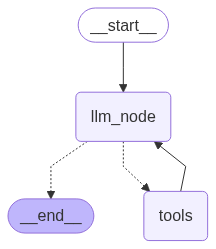

In [28]:
# Define LangGraph flow

graph_builder = StateGraph(State)

# Add Nodes
graph_builder.add_node('llm_node', invoke_chat_llm)
graph_builder.add_node('tools', ToolNode(tools,))  # Adding Tools Node with 4 tools. Node name MUST BE 'tools'

# Add Edges
graph_builder.add_edge(START, 'llm_node')
graph_builder.add_conditional_edges('llm_node', tools_condition) # LLM to a If .. Else conditional check.
# Sending response back to LLM to further resoning. If we need to END, set target as END.
graph_builder.add_edge('tools', 'llm_node')   

# Initialize Memory Object
memory = MemorySaver()

# Define a Thread_Id. Thread_Id is written to Memory for a Session.
# A Thread can be considered as a Collection of Checkpoints, al written to the Memory.
# Thread_Id is the Key for the Collection.
config = {'configurable': {'thread_id': 1001}}

# Compile Graph
graph = graph_builder.compile(checkpointer=memory, name='calc_tool')

# Visualize Graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Initiate Chat with AI Calculator

chat_prompt = []
exit_flag = False

def on_key_press(event):
    if event.name == 'esc':
        print("Escape key pressed! Exiting input.")
        global exit_flag
        exit_flag = True
        return True  # Stop the keyboard listener

# Keyboard Listener
keyboard.on_press(on_key_press)

# System Prompt - Set the Context for the bot.
system_prompt = input("What type Assistant should i be today: ")
chat_prompt = [SystemMessage(content=system_prompt)]

while(not exit_flag):
    user_prompt = input("User: ")
    if (not exit_flag):
        chat_prompt.append(HumanMessage(content=user_prompt))
        response = graph.invoke({'messages': chat_prompt}, config)
        print(response)

[SystemMessage(content='You are a helpful Math Assistant.', additional_kwargs={}, response_metadata={}, id='0b059caf-a9bb-4531-addb-f52af73e04bf'), HumanMessage(content='Add 10 and 5', additional_kwargs={}, response_metadata={}, id='e524a20d-c2da-4bbf-86a3-7a6a3e4689f3')]
content='' additional_kwargs={'tool_calls': [{'id': 'call_Xtv79GZNyRGoPO4iVHl03fgh', 'function': {'arguments': '{"num1":10,"num2":5}', 'name': 'addition'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 161, 'total_tokens': 181, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a288987b44', 'id': 'chatcmpl-C1052EEW4SvvvLDzrxSVOgpWcTMHn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='run--a26fd673-a9e3-49

In [ ]:
# Example - Invoke LLM with Chat Calculator Tools - Prompt 1

#prompt = [SystemMessage(content='You are a helpful Math Assistant.')]
#user_prompt = input("User: ") 
#prompt.append(HumanMessage(content=user_prompt))

#print(graph.invoke({'messages': prompt}, config))


[SystemMessage(content='You are a helpful Math Assistant.', additional_kwargs={}, response_metadata={}, id='a267135d-8a7f-41f7-a04b-1349f267b3b0'), HumanMessage(content='Add 10 and 5, then mutiply by 10 and divide it by 2', additional_kwargs={}, response_metadata={}, id='7bbfe934-b68d-4f42-b394-e882d19bf42c')]
content='' additional_kwargs={'tool_calls': [{'id': 'call_khrT048dhguRAntGgnXu2ruO', 'function': {'arguments': '{"num1": 10, "num2": 5}', 'name': 'addition'}, 'type': 'function'}, {'id': 'call_bWB15xhDKGC8VqdORldAd4kF', 'function': {'arguments': '{"num1": 15, "num2": 10}', 'name': 'multiply'}, 'type': 'function'}, {'id': 'call_g9S6LXkMyns1MhmLEIhhdBVZ', 'function': {'arguments': '{"num1": 150, "num2": 2}', 'name': 'divide'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 175, 'total_tokens': 249, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_pr

In [ ]:
# Scratch Pad

# Chaining the Tool usages
#prompt = [SystemMessage(content='You are a helpful Math Assistant.')]

# As a Test Chain the tool Usage like 
# Add 10 and 5, then mutiply by 10 and divide it by 2
# OR 'Add 10 and 5. Then multiply it with 10 and subract 50 from it.

#user_prompt = input("User: ") 
#prompt.append(HumanMessage(content=user_prompt))
#print(graph.invoke({'messages': prompt}, config))

# Using back to bac prompt with thread_id and Memory
# Prompt-1 - Add 10 and 5, then mutiply by 10 and divide it by 2
# Prompt-2 - Add 10 to the above.
# The AI answer should be 85.

# Prompt-3 - What is todays weather in Dallas, TX ?
# "I'm unable to provide real-time weather information. You can check a reliable weather website or app for the most current weather updates in Dallas, TX.
